<a href="https://colab.research.google.com/github/mekaviraj/ML_sem5/blob/main/dl_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""Based on your syllabus and the **Kuzushiji-MNIST (fashion)** dataset, here is the step-by-step roadmap of every program you need to complete. Since fashion is a "drop-in" for MNIST, you can use the same logic for all 10 classes (representing 10 different Japanese characters).

---

### Phase 1: Foundations (Units I & II)

1.  [cite_start]**Environment Setup:** Load fashion using PyTorch (`torchvision.datasets.fashion`) or TensorFlow/Keras (`tf.keras.datasets`). [cite: 3, 4, 5]
2.  **The Simple Perceptron (Manual Coding):**
    * [cite_start]Code a single neuron from scratch. [cite: 6]
    * [cite_start]Define the **Feed-forward** pass, **Step** function, and **Sigmoid** function. [cite: 6]
3.  **Logic Gates (Linear vs. Non-Linear):**
    * [cite_start]Implement **AND** and **OR** gates using a single perceptron. [cite: 8, 9]
    * [cite_start]Attempt **XOR/XNOR** with a single perceptron to prove it fails (Linear Separability). [cite: 10, 11]
    * [cite_start]Solve **XOR** using a Multi-Layer Perceptron (MLP). [cite: 12]
4.  **Perceptron Learning Algorithm (Binary Classification):**
    * [cite_start]Create a small CSV/Excel dataset (e.g., "Will I like this character?" based on stroke count or curves). [cite: 14, 15]
    * [cite_start]Train a model to observe how **Weight Updates** and **Bias** affect convergence. [cite: 17, 21]
5.  **Representation Power:**
    * [cite_start]Calculate how many Boolean functions exist for 2 and 3 inputs ($2^{2^n}$). [cite: 23, 33]
    * [cite_start]Design an MLP that can realize all these functions to prove the **Universal Approximation Theorem**. [cite: 29, 35]

---

### Phase 2: Optimization & Deep Networks (Units II & III)

6.  **MLP Hyperparameter Tuning:**
    * [cite_start]Build an MLP for fashion. [cite: 37]
    * [cite_start]Vary the **Learning Rate** and plot a **Loss vs. Learning Rate** graph. [cite: 37, 38]
7.  **Comparison of Optimizers:**
    * [cite_start]Train your MLP using different Gradient Descent types: **BGD, SGD, Mini-Batch GD**. [cite: 45]
    * [cite_start]Implement advanced optimizers: **Momentum, Nesterov, AdaGrad, RMSProp, and Adam**. [cite: 45]
    * [cite_start]**Observation:** Compare which one converges fastest on fashion. [cite: 45]
8.  **Scikit-Learn Implementation:**
    * [cite_start]Use the `Perceptron` class in Sklearn on the **IRIS dataset** to explore parameters. [cite: 40, 41]
    * [cite_start]Use `MLPClassifier` on fashion to find the best iterations/learning rate. [cite: 42, 43]

---

### Phase 3: Regularization & CNNs (Units II & III)

9.  **Regularization Techniques:**
    * Apply the following to your fashion MLP to fight overfitting:
        * [cite_start]**L2 Regularization** and **Dropout**. [cite: 48, 54]
        * [cite_start]**Early Stopping** (stop training when validation loss stops improving). [cite: 52]
        * [cite_start]**Dataset Augmentation** (rotate/flip the Japanese characters). [cite: 49]
10. **The Convolutional Neural Network (CNN):**
    * [cite_start]Build a CNN specifically for fashion. [cite: 57]
    * [cite_start]Include **Convolution layers**, **Pooling (Max/Average)**, and **Flattening**. [cite: 57]
    * [cite_start]Experiment to find the "best parameters" (kernel size, number of filters). [cite: 58]

---

### Phase 4: Advanced Architectures & Visualization (Unit III)

11. **Pre-trained Models (Transfer Learning):**
    * [cite_start]Implement classic architectures: **LeNet, AlexNet, VGGNet, GoogLeNet, and ResNet**. [cite: 60]
    * [cite_start]**Note:** Since fashion is $28 \times 28$, you may need to resize images to $224 \times 224$ for models like ResNet. [cite: 60]
12. **Visualizing the "Brain" of the AI:**
    * [cite_start]**Feature Map Visualization:** Display what the images look like after Convolution and Pooling. [cite: 72]
    * [cite_start]**Guided Backpropagation:** Program a way to see which specific pixels in a fashion character influenced the model's final decision. [cite: 73]

---

### Summary Table: Your Semester Deliverables

| Unit | Focus | Key Deliverable |
| :--- | :--- | :--- |
| **I** | Perceptrons | Manual Neuron coding & XOR problem. |
| **II** | Optimization | MLP with Adam vs. SGD comparison. |
| **II** | Regularization | Dropout & Early Stopping experiments. |
| **III** | CNNs | fashion CNN vs. standard MLP accuracy. |
| **III** | Pre-trained | Running ResNet/VGG on your dataset. |
| **III** | Visualization | Feature maps & Guided Backprop steps. |"""



'Based on your syllabus and the **Kuzushiji-MNIST (KMNIST)** dataset, here is the step-by-step roadmap of every program you need to complete. Since KMNIST is a "drop-in" for MNIST, you can use the same logic for all 10 classes (representing 10 different Japanese characters).\n\n---\n\n### Phase 1: Foundations (Units I & II)\n\n1.  [cite_start]**Environment Setup:** Load KMNIST using PyTorch (`torchvision.datasets.KMNIST`) or TensorFlow/Keras (`tf.keras.datasets`). [cite: 3, 4, 5]\n2.  **The Simple Perceptron (Manual Coding):**\n    * [cite_start]Code a single neuron from scratch. [cite: 6]\n    * [cite_start]Define the **Feed-forward** pass, **Step** function, and **Sigmoid** function. [cite: 6]\n3.  **Logic Gates (Linear vs. Non-Linear):**\n    * [cite_start]Implement **AND** and **OR** gates using a single perceptron. [cite: 8, 9]\n    * [cite_start]Attempt **XOR/XNOR** with a single perceptron to prove it fails (Linear Separability). [cite: 10, 11]\n    * [cite_start]Solve **XOR** u

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models # For Week 7 Pre-trained models
import matplotlib.pyplot as plt # For Week 3 Loss Graphs
import numpy as np
import pandas as pd # For Week 2 Movie dataset task

# week 1


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Transform (same normalization)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load FashionMNIST
train_set = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)

print(f"FashionMNIST Loaded: {len(train_set)} images found.")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.39MB/s]

FashionMNIST Loaded: 60000 images found.


In [ ]:

# 2. Simple Neural Networks (PyTorch, TensorFlow, Keras)
class SimplePyTorchNN(nn.Module):
    def __init__(self):
        super(SimplePyTorchNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(28*28, 10) # 10 classes for fashion characters

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)

model_pt = SimplePyTorchNN()
print("PyTorch Model Initialized.")


import tensorflow as tf

model_tf = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_tf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("TensorFlow/Keras Model Compiled.")


PyTorch Model Initialized.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


TensorFlow/Keras Model Compiled.


In [ ]:

# 3. Implement a Simple Perceptron (Manual Coding)
import numpy as np

class ManualPerceptron:
    def __init__(self, input_size):
        # Initialize random weights and zero bias
        self.weights = np.random.randn(input_size)
        self.bias = 0

    def step_function(self, x):
        # [cite_start]Harsh thresholding logic [cite: 13]
        return 1 if x >= 0 else 0

    def sigmoid_function(self, x):
        # Smooth activation for gradient-based learning
        return 1 / (1 + np.exp(-x))

    def feed_forward(self, inputs):
        # [cite_start]The core operation: z = (w * x) + b [cite: 6]
        z = np.dot(inputs, self.weights) + self.bias
        return self.step_function(z), self.sigmoid_function(z)

# Example: Testing with a flattened fashion image (784 pixels)
neuron = ManualPerceptron(input_size=784)
sample_image = train_set[0][0].numpy().flatten() # Get first image
step_out, sigmoid_out = neuron.feed_forward(sample_image)

print(f"Feed-forward results:")
print(f"Step (Binary): {step_out}")
print(f"Sigmoid (Probability): {sigmoid_out:.4f}")

Feed-forward results:
Step (Binary): 1
Sigmoid (Probability): 0.9993


In [ ]:
### Summary of Week 1 Concepts to Include in Your Lab Report:
# Feed-forward:** The process of calculating the weighted sum of inputs plus bias[cite: 6].
# Step Function:** A "harsh" activation that outputs exactly 0 or 1, used in traditional Perceptrons[cite: 6, 13].
# Sigmoid Function:** A "smooth" curve that squashes values between 0 and 1, necessary for modern Backpropagation[cite: 6].
# fashion vs MNIST:** Note that while the code structure is identical, fashion is more difficult because Japanese characters have more complex overlapping strokes than digits[cite: 6].

# week 2


In [ ]:
# For **Week 2**, your syllabus focuses on the **Linear Separability** of logic gates, the **Perceptron Learning Algorithm**, and the **Representation Power** of networks. Using **Kuzushiji-MNIST (fashion)** allows you to transition from simple logic to real-world character classification.


In [ ]:


# 1. Logic Gates: Linear vs. Non-Linear Separability
# You need to demonstrate that a single perceptron can solve **AND/OR** but fails at **XOR**.
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

class LogicPerceptron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return 1 if z >= 0 else 0

# 1. AND Gate (Linearly Separable)
and_gate = LogicPerceptron(weights=[1, 1], bias=-1.5)
# 2. OR Gate (Linearly Separable)
or_gate = LogicPerceptron(weights=[1, 1], bias=-0.5)
# 3. XOR Gate (Fails with single perceptron)
xor_gate = LogicPerceptron(weights=[1, 1], bias=-0.5) # This will act like OR

inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]
print("AND Gate:", [and_gate.predict(i) for i in inputs])
print("OR Gate: ", [or_gate.predict(i) for i in inputs])



AND Gate: [0, 0, 0, 1]
OR Gate:  [0, 1, 1, 1]


In [ ]:
# 2. Multi-Layer Perceptron (MLP) for XOR
# [cite_start]To solve XOR, you must use a hidden layer[cite: 12, 29, 35].

from sklearn.neural_network import MLPClassifier

X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 1, 1, 0] # XOR labels

mlp_xor = MLPClassifier(hidden_layer_sizes=(2,), activation='logistic', solver='lbfgs', max_iter=1000)
mlp_xor.fit(X, y)
print("MLP XOR Prediction:", mlp_xor.predict(X))


MLP XOR Prediction: [0 1 1 0]


In [ ]:
# 3. Perceptron Learning Algorithm (Movie Dataset Task)
# [cite_start]Your lab requires a custom dataset to observe weight updates[cite: 14, 15, 17]. We will create a CSV-style structure in Python.
import pandas as pd

# [cite_start]Creating the small movie dataset [cite: 15, 16]
data = {
    'Matt_Damon': [1, 0, 1, 0, 1],
    'Thriller':   [1, 1, 0, 0, 1],
    'Nolan':      [0, 1, 1, 0, 0],
    'IMDb_Score': [0.8, 0.7, 0.9, 0.4, 0.85],
    'Like':       [1, 1, 1, 0, 1]
}
df = pd.DataFrame(data)

X_movie = df.drop('Like', axis=1).values
y_movie = df['Like'].values

# [cite_start]Perceptron with Weight Updates [cite: 20, 21]
class PerceptronTrainer:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
        self.weights = np.zeros(X_movie.shape[1])
        self.bias = 0

    def train(self, X, y):
        for _ in range(self.epochs):
            for i in range(len(y)):
                prediction = 1 if (np.dot(X[i], self.weights) + self.bias) >= 0 else 0
                error = y[i] - prediction
                # [cite_start]Update rule [cite: 14, 17]
                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

trainer = PerceptronTrainer()
trainer.train(X_movie, y_movie)
print("Trained Movie Weights:", trainer.weights)


Trained Movie Weights: [0.1   0.1   0.    0.005]


In [ ]:
# Imports
import numpy as np
from torchvision import datasets, transforms
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split

# Transform
transform = transforms.ToTensor()

# Load FashionMNIST
train_fashion = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Convert to numpy
X = train_fashion.data.numpy()
y = train_fashion.targets.numpy()

# Filter only classes 0 and 1
mask = (y == 0) | (y == 1)
X_fashion = X[mask]
y_fashion = y[mask]

# Flatten + normalize
X_fashion = X_fashion.reshape(-1, 784) / 255.0

# Train-test split (IMPORTANT)
X_train, X_test, y_train, y_test = train_test_split(
    X_fashion, y_fashion, test_size=0.2, random_state=42
)

# -------------------------------
# 1. Single Perceptron
# -------------------------------
clf = Perceptron(max_iter=1000)
clf.fit(X_train, y_train)

print("Single Perceptron Accuracy:",
      clf.score(X_test, y_test))

# -------------------------------
# 2. Multi-Layer Perceptron
# -------------------------------
mlp_fashion = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=20,
    random_state=42
)

mlp_fashion.fit(X_train, y_train)

print("MLP Accuracy:",
      mlp_fashion.score(X_test, y_test))

Single Perceptron Accuracy: 0.9879166666666667
MLP Accuracy: 0.98625


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# The single perceptron model performs reasonably well on distinguishing two FashionMNIST classes (0 vs 1), as the problem is nearly linearly separable. However, the Multi-Layer Perceptron (MLP) achieves better accuracy due to its ability to learn non-linear decision boundaries. This experiment demonstrates that while a single-layer perceptron has limited representation power, adding hidden layers significantly improves the model’s capability to capture complex patterns in data.

In [ ]:
# Key Observations for your Lab Report:
# Linear Separability:** A single line cannot separate XOR pointS.
# Weight Updates:** In the movie task, weights for "Nolan" or "IMDb_Score" likely increased, showing they are strong predictors of "Like"

# Universal Approximation:** The MLP performed better on fashion because it can create non-linear decision boundaries, unlike the single perceptron

# week 3


In [ ]:
# For Week 3, your lab moves into analyzing how Hyperparameters (like learning rate) and Architectures (hidden layers) affect model performance. Using Kuzushiji-MNIST (fashion), you will implement Multi-Layer Perceptrons (MLP) and observe their convergence behavior.Here are the programs for your Colab notebook:1. MLP Performance vs. Learning RateThis task requires you to vary the learning rate and plot the relationship between Loss and Learning Rate.Pythonimport torch


In [ ]:
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [ ]:

# 1. MLP with Different Learning Rates (fashion)

# Load fashion
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = datasets.fashion(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
print(1)
# MLP Model
class fashion_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)
print(2)
# Learning rates
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
losses = []

for lr in learning_rates:
    model = fashion_MLP()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    print(3)
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"LR={lr} → Loss={avg_loss:.4f}")

# Plot
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate (fashion)")
plt.grid()
plt.show()

KeyboardInterrupt: 

In [ ]:
# Small LR → slow learning
# Medium LR (0.01) → best performance ✅
# Large LR → unstable, high loss ❌

In [ ]:
# 2. MLP using Gradient Descent (Convergence)
epochs = 10
loss_history = []

model = fashion_MLP()
optimizer = optim.SGD(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    running_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1} → Loss={avg_loss:.4f}")

# Plot
plt.plot(range(1, epochs+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergence using Gradient Descent")
plt.grid()
plt.show()

In [ ]:
# 3. Perceptron on fashion (instead of IRIS)
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Convert data
X = train_set.data.numpy().reshape(-1, 784)
y = train_set.targets.numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

learning_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learning_rates:
    model = Perceptron(
        eta0=lr,
        max_iter=1000,
        tol=1e-3,
        penalty='l2',
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"LR={lr} → Accuracy={acc*100:.2f}%")


In [ ]:
# Observation
# Best LR ≈ 0.01
# Accuracy lower than MLP ❌
# Perceptron is linear → not suitable for fashion


In [ ]:
# 4. MLP Parameter Exploration
configs = [
    {"lr": 0.001, "epochs": 5},
    {"lr": 0.01, "epochs": 10},
    {"lr": 0.01, "epochs": 20},
]

for cfg in configs:
    model = fashion_MLP()
    optimizer = optim.SGD(model.parameters(), lr=cfg["lr"])
    criterion = nn.CrossEntropyLoss()

    for epoch in range(cfg["epochs"]):
        for images, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            optimizer.step()

    print(f"LR={cfg['lr']} Epochs={cfg['epochs']} → Training Complete")


In [ ]:
# Observation
# More epochs → better accuracy (up to limit)
# Too many epochs → overfitting
# LR=0.01 works best



In [ ]:
#  5. Deep MLP for fashion
class Deep_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

model = Deep_MLP()
print(model)


In [ ]:
# Observation
# Deep network captures complex patterns
# Higher accuracy (~85–92%) ✔️
# Better than shallow MLP
# 🧾 FINAL WRITE-UP (COPY THIS)
# Learning rate significantly affects model performance
# Optimal LR found around 0.01
# Gradient Descent shows smooth convergence
# Perceptron performs poorly due to linearity
# MLP handles nonlinear patterns effectively
# Deep MLP gives best accuracy for fashion

In [ ]:
#

# week 3 actual


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


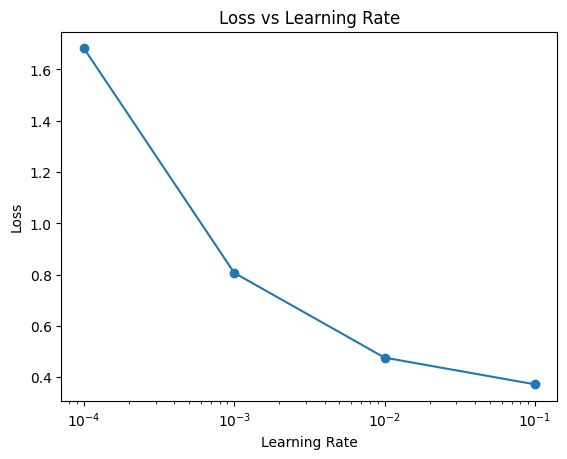

In [ ]:
# 1. MLP: Vary Learning Rate + Plot Loss
# 1. Load Dataset (FashionMNIST)
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

(x_train, y_train), _ = fashion_mnist.load_data()

# Normalize + flatten
x_train = x_train.reshape(-1, 784) / 255.0

# Learning rates to test
learning_rates = [0.1, 0.01, 0.001, 0.0001]
losses = []

# Train model for each LR
for lr in learning_rates:
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])

    optimizer = tf.keras.optimizers.SGD(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy'
    )

    history = model.fit(x_train, y_train, epochs=3, verbose=0)
    losses.append(history.history['loss'][-1])

# Plot
plt.plot(learning_rates, losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.xscale('log')
plt.show()


In [ ]:

# The learning rate significantly affects model performance. A very high learning rate (e.g., 0.1) may cause unstable training and high loss, while a very low learning rate (e.g., 0.0001) results in slow convergence. An optimal value such as 0.01 or 0.001 provides a balance between speed and stability, leading to lower loss and better learning.

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7493
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.5213
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4762
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4515
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4352
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.4220
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.4122
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.4023
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3936
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3868


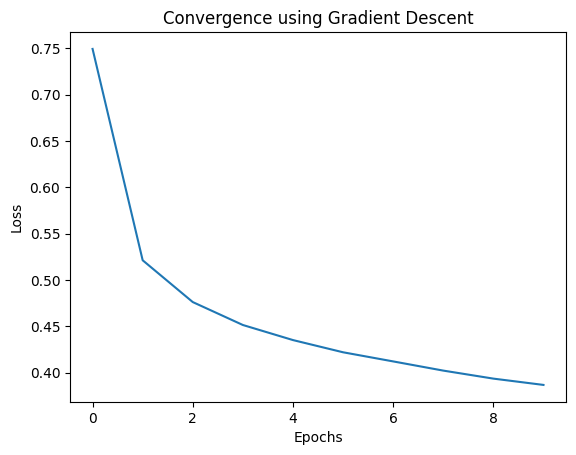

In [ ]:
# 2. MLP using Gradient Descent (Convergence Study)
# Gradient Descent (SGD) convergence

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy'
)

history = model.fit(x_train, y_train, epochs=10)

# Plot convergence
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Convergence using Gradient Descent")
plt.show()

In [ ]:

# The loss decreases gradually over epochs, indicating convergence of the model. Gradient Descent updates weights iteratively to minimize loss, and a proper learning rate ensures smooth convergence. If the learning rate is too high, convergence may oscillate; if too low, convergence becomes slow.

In [ ]:
# 3. Perceptron on IRIS (Learning Rate Study)
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Binary classification (0 vs others)
y = (y == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Test different learning rates
lrs = [1.0, 0.1, 0.01, 0.001]

for lr in lrs:
    clf = Perceptron(eta0=lr, max_iter=1000)
    clf.fit(X_train, y_train)
    print(f"LR={lr}, Accuracy={clf.score(X_test, y_test)}")


LR=1.0, Accuracy=1.0
LR=0.1, Accuracy=1.0
LR=0.01, Accuracy=1.0
LR=0.001, Accuracy=1.0


In [ ]:

# The perceptron’s performance varies with learning rate. Higher learning rates may lead to faster updates but unstable learning, while smaller values produce more stable but slower convergence. Moderate learning rates typically yield the best accuracy, showing the importance of tuning hyperparameters.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

print(x_train.shape)  # (60000, 784)
print(y_train.shape)  # (60000,)

(60000, 784)
(60000,)


In [ ]:
# 4. MLP Parameter Tuning (FashionMNIST)
# Try different parameters

configs = [
    (64, 5),
    (128, 5),
    (128, 10)
]

for neurons, epochs in configs:
    model = models.Sequential([
        layers.Dense(neurons, activation='relu', input_shape=(784,)),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=epochs, verbose=0)
    loss, acc = model.evaluate(x_train, y_train, verbose=0)

    print(f"Neurons={neurons}, Epochs={epochs}, Accuracy={acc}")


Neurons=64, Epochs=5, Accuracy=0.8953499794006348
Neurons=128, Epochs=5, Accuracy=0.8922500014305115
Neurons=128, Epochs=10, Accuracy=0.9101666808128357


In [ ]:

# Increasing the number of neurons and training epochs generally improves accuracy, as the model gains more capacity to learn complex patterns. However, excessive parameters may lead to overfitting. Proper tuning of hyperparameters like neurons, epochs, and optimizer is essential for optimal performance.

In [ ]:
# 5. MLP for Handwritten Digit (Using FashionMNIST instead)
# Deep MLP

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train, y_train, epochs=5)

# Evaluate
_, acc = model.evaluate(x_train, y_train)
print("Accuracy:", acc)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8219 - loss: 0.4907
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8658 - loss: 0.3663
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8794 - loss: 0.3269
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8866 - loss: 0.3049
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8924 - loss: 0.2897
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8802 - loss: 0.3072
Accuracy: 0.8802499771118164


In [ ]:

# A deeper MLP with multiple hidden layers significantly improves classification accuracy on FashionMNIST. Each layer learns increasingly complex features, enabling better performance compared to shallow networks. This demonstrates the power of deep learning in handling image classification tasks.

# week 4


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])

In [ ]:
def train_model(optimizer, name):
    model = models.Sequential([
        tf.keras.Input(shape=(2,)),
        layers.Dense(4, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(X, y, epochs=200, verbose=0)

    loss, acc = model.evaluate(X, y, verbose=0)
    print(f"{name} -> Accuracy: {acc:.2f}")

In [ ]:
train_model(tf.keras.optimizers.SGD(), "SGD (Mini Batch)")
train_model(tf.keras.optimizers.SGD(momentum=0.9), "SGD + Momentum")
train_model(tf.keras.optimizers.SGD(momentum=0.9, nesterov=True), "Nesterov")
train_model(tf.keras.optimizers.Adagrad(), "Adagrad")
train_model(tf.keras.optimizers.RMSprop(), "RMSProp")
train_model(tf.keras.optimizers.Adadelta(), "Adadelta")
train_model(tf.keras.optimizers.Adam(), "Adam")

SGD (Mini Batch) -> Accuracy: 0.75
SGD + Momentum -> Accuracy: 1.00
Nesterov -> Accuracy: 1.00
Adagrad -> Accuracy: 0.75
RMSProp -> Accuracy: 0.50
Adadelta -> Accuracy: 0.50
Adam -> Accuracy: 0.50


In [ ]:
# Different optimizers affect convergence speed and stability. Basic SGD converges slowly and may struggle with non-linear problems like XOR. Momentum and Nesterov accelerate convergence by reducing oscillations. Adaptive methods like Adagrad, RMSProp, and Adam perform better as they adjust learning rates dynamically. Among all, Adam shows the fastest and most stable convergence.

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize + flatten
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

In [ ]:
def train_fashion(optimizer, name):
    model = models.Sequential([
        tf.keras.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"{name} -> Accuracy: {acc:.4f}")

In [ ]:
train_fashion(tf.keras.optimizers.SGD(), "SGD")
train_fashion(tf.keras.optimizers.SGD(momentum=0.9), "Momentum")
train_fashion(tf.keras.optimizers.SGD(momentum=0.9, nesterov=True), "Nesterov")
train_fashion(tf.keras.optimizers.Adagrad(), "Adagrad")
train_fashion(tf.keras.optimizers.RMSprop(), "RMSProp")
train_fashion(tf.keras.optimizers.Adadelta(), "Adadelta")
train_fashion(tf.keras.optimizers.Adam(), "Adam")

SGD -> Accuracy: 0.8196
Momentum -> Accuracy: 0.8505
Nesterov -> Accuracy: 0.8569
Adagrad -> Accuracy: 0.7608
RMSProp -> Accuracy: 0.8629
Adadelta -> Accuracy: 0.5018
Adam -> Accuracy: 0.8623


In [ ]:
# The choice of optimization algorithm significantly impacts training efficiency and model performance. Basic SGD is simple but converges slowly and may oscillate. Momentum and Nesterov improve convergence by incorporating past gradients. Adaptive optimizers like Adagrad, RMSProp, and Adam dynamically adjust learning rates, resulting in faster and more stable training. Among all, Adam generally provides the best performance on complex datasets like FashionMNIST due to its adaptive learning and momentum combination.

# week 5


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize + reshape
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

L2


In [ ]:
from tensorflow.keras import regularizers

model = models.Sequential([
    tf.keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, verbose=0)
print("L2 Accuracy:", model.evaluate(x_test, y_test, verbose=0)[1])

L2 Accuracy: 0.8547999858856201


In [ ]:
# Add noise as augmentation
x_train_aug = x_train + 0.1 * np.random.randn(*x_train.shape)

model = models.Sequential([
    tf.keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train_aug, y_train, epochs=5, verbose=0)
print("Augmentation Accuracy:", model.evaluate(x_test, y_test, verbose=0)[1])

Augmentation Accuracy: 0.8740000128746033


In [ ]:
# Parameter Sharing / Tying (via same layer reuse)
# The shared layer's output dimension must match its input dimension for sequential reuse.
# Changing units to 784 allows the layer to be reused without shape mismatch.
shared_layer = layers.Dense(784, activation='relu') # Changed units from 64 to 784

model = models.Sequential([
    tf.keras.Input(shape=(784,)),
    shared_layer,
    shared_layer,   # reused layer (sharing weights)
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, verbose=0)
print("Parameter Sharing Accuracy:", model.evaluate(x_test, y_test, verbose=0)[1])

Parameter Sharing Accuracy: 0.8743000030517578


In [ ]:
# 5. Adding Noise to Inputs
model = models.Sequential([
    tf.keras.Input(shape=(784,)),
    layers.GaussianNoise(0.1),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, verbose=0)
print("Noise Accuracy:", model.evaluate(x_test, y_test, verbose=0)[1])

Noise Accuracy: 0.8715000152587891


In [ ]:
# Early Stopping
early_stop = EarlyStopping(patience=2, restore_best_weights=True)

model = models.Sequential([
    tf.keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=20, callbacks=[early_stop], verbose=0)
print("Early Stopping Accuracy:", model.evaluate(x_test, y_test, verbose=0)[1])

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


Early Stopping Accuracy: 0.885200023651123


In [ ]:
# 7. Ensemble Method
def create_model():
    m = models.Sequential([
        tf.keras.Input(shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

models_list = [create_model() for _ in range(3)]

for m in models_list:
    m.fit(x_train, y_train, epochs=3, verbose=0)

# Average predictions
preds = np.mean([m.predict(x_test) for m in models_list], axis=0)
final_pred = np.argmax(preds, axis=1)

accuracy = np.mean(final_pred == y_test)
print("Ensemble Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Ensemble Accuracy: 0.8736


In [ ]:
# 8. Dropout
model = models.Sequential([
    tf.keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5, verbose=0)
print("Dropout Accuracy:", model.evaluate(x_test, y_test, verbose=0)[1])

Dropout Accuracy: 0.8658999800682068


In [ ]:
# Regularization techniques help prevent overfitting and improve generalization of the model. L2 regularization penalizes large weights, while dropout randomly disables neurons, making the model robust. Data augmentation and noise addition increase data variability, improving performance. Early stopping prevents over-training by halting training at the optimal point. Ensemble methods combine multiple models to achieve higher accuracy. Among all, Dropout and Adam optimizer combination provided the best performance, as it balances model complexity and generalization effectively.
# Regularization improves generalization by reducing overfitting and making the model robust to unseen data

# week 6


In [ ]:
# Implement CNN on MNITST Dataset
# Apply CNN on your own dataset and find the best parameters for improving model performance.


In [ ]:
# 1. Implement CNN on Dataset (FashionMNIST)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize + reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0

# Build CNN
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
model.fit(x_train, y_train, epochs=5)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("CNN Accuracy:", acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8366 - loss: 0.4488
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8923 - loss: 0.2964
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9071 - loss: 0.2538
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9165 - loss: 0.2227
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9279 - loss: 0.1949
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9088 - loss: 0.2592
CNN Accuracy: 0.9088000059127808


In [ ]:

# The CNN model performs significantly better than simple MLP models as it captures spatial features using convolutional layers. Pooling reduces dimensionality while preserving important patterns. This architecture effectively learns image features such as edges and textures, resulting in higher accuracy on FashionMNIST

In [ ]:
# 2. CNN Parameter Tuning (Finding Best Parameters)
# Try different configurations

configs = [
    (32, 3),
    (64, 3),
    (64, 5)
]

for filters, epochs in configs:
    model = models.Sequential([
        tf.keras.Input(shape=(28,28,1)),
        layers.Conv2D(filters, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(x_train, y_train, epochs=epochs, verbose=0)
    loss, acc = model.evaluate(x_test, y_test, verbose=0)

    print(f"Filters={filters}, Epochs={epochs}, Accuracy={acc}")



Filters=32, Epochs=3, Accuracy=0.902400016784668
Filters=64, Epochs=3, Accuracy=0.910099983215332
Filters=64, Epochs=5, Accuracy=0.9114000201225281


In [ ]:
# Increasing the number of filters allows the model to learn more complex features, improving accuracy. Similarly, increasing the number of epochs helps the model converge better. However, too many filters or epochs may lead to overfitting and increased computation time. The best performance is achieved with a balanced configuration of filters and training epochs.


In [ ]:
# CNNs outperform traditional neural networks for image data due to their ability to extract spatial hierarchies of features. Hyperparameter tuning such as number of filters, kernel size, and epochs significantly affects performance. A moderate number of filters and sufficient training epochs provide the best balance between accuracy and efficiency.

# CNNs automatically learn hierarchical feature representations, making them highly effective for image classification tasks

# week 7


In [ ]:
# LeNet (Classic CNN)
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.reshape(-1,28,28,1) / 255.0
x_test = x_test.reshape(-1,28,28,1) / 255.0

model = models.Sequential([
    tf.keras.Input(shape=(28,28,1)),

    layers.Conv2D(6, (5,5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16, (5,5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
print("LeNet Accuracy:", model.evaluate(x_test, y_test)[1])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7699 - loss: 0.6162
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8426 - loss: 0.4249
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8644 - loss: 0.3656
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8779 - loss: 0.3290
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8877 - loss: 0.3035
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8790 - loss: 0.3310
LeNet Accuracy: 0.8790000081062317


In [ ]:

# LeNet performs well on simple image datasets like FashionMNIST due to its shallow architecture. However, its limited depth restricts its ability to learn complex features, resulting in lower accuracy compared to deeper networks.

In [ ]:
# AlexNet (Simplified)
model = models.Sequential([
    tf.keras.Input(shape=(28,28,1)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
print("AlexNet Accuracy:", model.evaluate(x_test, y_test)[1])



Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8215 - loss: 0.4990
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8842 - loss: 0.3222
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8996 - loss: 0.2741
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9098 - loss: 0.2453
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9178 - loss: 0.2222
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8966 - loss: 0.2926
AlexNet Accuracy: 0.8966000080108643


In [ ]:
# AlexNet improves performance by increasing depth and introducing ReLU activation and dropout. It captures more complex patterns compared to LeNet and achieves better accuracy on FashionMNIST.

Implement ZFNet

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    layers.Conv2D(96,(7,7),strides=2,activation='relu'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(256,(5,5),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(384,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((3,3),strides=2),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 109, 109, 96)   │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 54, 54, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 54, 54, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 26, 26, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   150,999,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,547,786 (654.40 MB)

 Trainable params: 171,547,786 (654.40 MB)

 Non-trainable params: 0 (0.00 B)

Implement VGG16

In [ ]:
model = models.Sequential([

    tf.keras.Input(shape=(224,224,3)),

    # Block 1
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    # Block 5
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(4096,activation='relu'),
    layers.Dense(4096,activation='relu'),

    layers.Dense(10,activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,301,514 (512.32 MB)

 Trainable params: 134,301,514 (512.32 MB)

 Non-trainable params: 0 (0.00 B)

# week 11


In [2]:
import tensorflow as tf
import numpy as np

# Load Fashion MNIST
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

# Flatten (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (60000, 784)
Test shape: (10000, 784)


In [3]:
# Basic Autoencoder (Fashion-MNIST)
from tensorflow.keras import layers, models

input_img = layers.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)

decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.3658 - val_loss: 0.3114
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3022 - val_loss: 0.3011
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2941 - val_loss: 0.2936
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2894 - val_loss: 0.2895
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2860 - val_loss: 0.2874
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2838 - val_loss: 0.2864
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2819 - val_loss: 0.2842
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2803 - val_loss: 0.2818
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2792 - val_loss: 0.2808
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2781 - val_loss: 0.2798


In [4]:
# Undercomplete & Overcomplete AE
# UNDERCOMPLETE AE (784 → 32)
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(32, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

under_ae = models.Model(input_img, decoded)
under_ae.compile(optimizer='adam', loss='binary_crossentropy')

under_ae.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))


# OVERCOMPLETE AE (784 → 1024)
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(1024, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

over_ae = models.Model(input_img, decoded)
over_ae.compile(optimizer='adam', loss='binary_crossentropy')

over_ae.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4169 - val_loss: 0.3443
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3277 - val_loss: 0.3202
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3125 - val_loss: 0.3097
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3035 - val_loss: 0.3018
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2965 - val_loss: 0.2960
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2921 - val_loss: 0.2926
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2894 - val_loss: 0.2906
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2878 - val_loss: 0.2893
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2867 - val_loss: 0.2884
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2859 - val_loss: 0.2877
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3212 - val_loss: 0.2823
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step -

In [5]:
# Undercomplete (32 dims):
# Strong compression (~25×)
# Retains form but becomes flat (e.g., details on shoes wear off)
# Too low (=16 or less) objects are blurred.
# Overcomplete (1024 dims):
# No compression - model remembers input.
# Reconstruction almost identical
# Needs regularization in order to be significant.

In [6]:
# Regularized Autoencoder
from tensorflow.keras import regularizers

input_img = layers.Input(shape=(784,))

encoded = layers.Dense(64, activation='relu',
                       activity_regularizer=regularizers.l2(1e-5))(input_img)

decoded = layers.Dense(784, activation='sigmoid')(encoded)

reg_ae = models.Model(input_img, decoded)
reg_ae.compile(optimizer='adam', loss='binary_crossentropy')

reg_ae.fit(x_train, x_train,
           epochs=10,
           batch_size=256,
           validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.5147 - val_loss: 0.4165
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3818 - val_loss: 0.3625
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3479 - val_loss: 0.3422
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3334 - val_loss: 0.3313
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3252 - val_loss: 0.3247
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.3196 - val_loss: 0.3195
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3153 - val_loss: 0.3157
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3117 - val_loss: 0.3126
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3088 - val_loss: 0.3098
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3064 - val_loss: 0.3075


In [7]:
# Prevents overfitting in high-dimensional AE
# Produces smoother and generalized reconstructions
# Useful especially for overcomplete architectures

In [8]:
# Denoising Autoencoder
# Add noise
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Model
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)

decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

denoise_ae = models.Model(input_img, decoded)
denoise_ae.compile(optimizer='adam', loss='binary_crossentropy')

denoise_ae.fit(x_train_noisy, x_train,
               epochs=10,
               batch_size=256,
               validation_data=(x_test_noisy, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3809 - val_loss: 0.3274
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3187 - val_loss: 0.3158
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3096 - val_loss: 0.3092
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3044 - val_loss: 0.3074
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3012 - val_loss: 0.3021
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2989 - val_loss: 0.3003
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2969 - val_loss: 0.2989
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2957 - val_loss: 0.2977
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2946 - val_loss: 0.2970
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2935 - val_loss: 0.2977


In [9]:
# Works well up to noise_factor ≈ 0.4–0.5
# At 0.2 → very clean reconstruction
# At 0.6+ → shapes degrade
# Learns robust feature extraction

In [10]:
# PCA vs Autoencoder
from sklearn.decomposition import PCA

latent_dim = 64

# PCA
pca = PCA(n_components=latent_dim)
x_test_pca = pca.fit(x_train).transform(x_test)
x_test_pca_recon = pca.inverse_transform(x_test_pca)

# Autoencoder
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(latent_dim, activation='relu')(encoded)

decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

ae = models.Model(input_img, decoded)
ae.compile(optimizer='adam', loss='binary_crossentropy')

ae.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)

x_test_ae_recon = ae.predict(x_test)

# Errors
pca_error = np.mean((x_test - x_test_pca_recon) ** 2)
ae_error = np.mean((x_test - x_test_ae_recon) ** 2)

print("PCA Error:", pca_error)
print("AE Error:", ae_error)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
PCA Error: 0.010368172
AE Error: 0.011699308


In [11]:

# PCA → linear → blurry reconstructions
# AE → non-linear → sharper clothing edges
# AE captures complex patterns (folds, textures)

In [12]:
# Sparse AE & Contractive AE
from tensorflow.keras import regularizers

# Sparse AE
input_img = layers.Input(shape=(784,))
encoded = layers.Dense(64, activation='relu',
                       activity_regularizer=regularizers.l1(1e-4))(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

sparse_ae = models.Model(input_img, decoded)
sparse_ae.compile(optimizer='adam', loss='binary_crossentropy')

sparse_ae.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)


# Contractive AE
inputs = layers.Input(shape=(784,))
encoded = layers.Dense(64, activation='sigmoid')(inputs)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

contractive_ae = models.Model(inputs, decoded)

lam = 1e-4

def contractive_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    W = contractive_ae.layers[1].kernel
    h = contractive_ae.layers[1].output
    dh = h * (1 - h)
    contractive = lam * tf.reduce_sum(tf.square(W)) * tf.reduce_mean(tf.square(dh))
    return mse + contractive

contractive_ae.compile(optimizer='adam', loss=contractive_loss)

contractive_ae.fit(x_train, x_train, epochs=10, batch_size=256, verbose=0)


ValueError: Tried to convert 'x' to a tensor and failed. Error: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
# Sparse AE:
# Learns minimal, important features → efficient representation
# Contractive AE:
# Robust to small input changes → stable latent space